<a href="https://colab.research.google.com/github/czechuuu/micro-vla/blob/main/MicroVla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MIMUW Reinforcement Learning 26/26L

Adrian Boguszewski, Bartosz Czechowski

# Project statement
## Overview & Motivation
Vision-Language-Action (VLA) models, such as RT-2 and OpenVLA, have recently demonstrated incredible zero-shot generalization in robotics. However, these models face a severe data bottleneck: while we have massive repositories of video data showing humans or robots completing tasks, we have very little action-annotated data containing the exact motor torques and joint commands required to replicate those movements.
Standard supervised approaches fail when actions are missing. If we can design architectures that learn world dynamics and physics directly from "observation-only" videos, we can vastly expand the training sets for robotic foundation models. This project explores whether pre-training on a large corpus of action-free manipulation videos can improve a small-scale VLA's ability to perform In-Context Learning (ICL) from just one or two fully annotated demonstrations.
## Project Objective
The primary goal of this project is to build a "Micro-VLA" agent that improves its sample efficiency and few-shot generalization by learning from unannotated video trajectories. The student will implement a system that uses an Inverse Dynamics Model (or masked token prediction) to ingest observation-only sequences from a simulated robotics environment, combining this with a small set of action-annotated data to solve continuous control manipulation tasks.
## Expected Deliverables (Pass Criteria)
To successfully pass this project, students are expected to complete the following concrete tasks:
- **Simulated Benchmark Setup**: Set up a lightweight, continuous-control robotic manipulation environment (e.g., Robomimic or Meta-World). Generate a synthetic dataset: a small fraction containing full state-action-reward data, and a large fraction stripped of actions to simulate "video-only" observations.
- **Architecture Implementation**: Design a small Transformer-based policy (e.g., a miniaturized Decision Transformer). Implement an auxiliary objective, such as an Inverse Dynamics module, that forces the network to predict the missing actions between two consecutive video frames, allowing it to learn from the observation-only dataset.
- **Benchmarking & Evaluation**: Train two models: a baseline Micro-VLA trained strictly on the small, fully-annotated dataset, and your proposed Micro-VLA trained on the mixed dataset.
- **Comparative Analysis**: Deliver a final report evaluating the models on their In-Context Learning capabilities. Specifically, prompt the frozen models with a single successful demonstration of a new, unseen task variation (e.g., picking up a differently colored object) and measure which model exhibits better zero-shot or few-shot transfer.


# 1. Common

## Dependencies

In [ ]:
! pip install robosuite imageio imageio-ffmpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 896.8/896.8 kB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 10.9 MB/s eta 0:00:

## Helpers

In [ ]:
import numpy as np
from scipy.spatial.transform import Rotation as R

def extract_7dof_state(obs):
    """
    Converts raw robosuite observations into a standardized 7-DoF state representation.

    Args:
        obs (dict): Dictionary containing the observation arrays.
                    Required keys: 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos'

    Returns:
        np.ndarray: An array of shape (N, 7) containing (x, y, z, roll, pitch, yaw, gripper_width)
    """
    # 1. Translation: (x, y, z)
    pos = np.atleast_2d(obs['robot0_eef_pos'])

    # 2. Rotation: (roll, pitch, yaw)
    quat = np.atleast_2d(obs['robot0_eef_quat'])
    # Robosuite outputs (x, y, z, w), which is exactly what Scipy expects
    rpy = R.from_quat(quat).as_euler('xyz', degrees=False)

    # 3. Gripper Width: Left Finger (0) - Right Finger (1)
    gripper_qpos = np.atleast_2d(obs['robot0_gripper_qpos'])
    width = gripper_qpos[:, 0] - gripper_qpos[:, 1]

    # Expand width dimensions from (N,) to (N, 1) to match the other arrays
    width = np.expand_dims(width, axis=-1)

    # 4. Concatenate into a single (N, 7) state vector
    state_7dof = np.concatenate([pos, rpy, width], axis=-1)

    # If the input was a single timestep, return a 1D array instead of (1, 7)
    if state_7dof.shape[0] == 1 and obs['robot0_eef_pos'].ndim == 1:
        return state_7dof[0]

    return state_7dof

## Config

In [ ]:
from dataclasses import dataclass, field
import torch

@dataclass
class Config:
    model_id: str | None = None
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    action_dim: tuple[int] = (7,)
    obs_dim: tuple[int] = (7,)

    num_epochs: int = 1
    steps_per_epoch: int = 9000
    batch_size: int = 8

    context_len: int = 75       # How many timesteps of history of a single trajectory the model looks at - with ICL the model can attend to more than context len
    max_ep_len: int = 200         # Max episode length (needed for positional embeddings, Robosuite default is 500)
    hidden_dim: int = 256         # Transformer embedding dimension
    num_layers: int = 3           # Number of Transformer blocks
    nhead: int = 4                # Number of attention heads
    dropout: float = 0.1
    image_size: int = 512
    vision_embed_dim: int = 512
    target_return: float = 15.5
    use_reward_tokens: bool = False
    use_rtg: bool = False # Only valid if use_reward_tokens = True. Decides whether to use RTG or standard step-wise rewards.
    fuse_observations: bool = False # Whether we should fuse cameras and proprio into one latent token or let them be separate.


    dataset_stats: dict = field(
        default_factory=lambda: {
            "observation.state": {
                "mean": torch.tensor([
                    -0.02250661411056904,
                    -0.0017509463337428896,
                    0.8927278452815375,
                    0.14772878979109655,
                    -0.09987207042179344,
                    0.028312488183443292,
                    0.06784597426917023
                ], dtype=torch.float32),
                "std": torch.tensor([
                    0.04077795730302498,
                    0.0156866066296251,
                    0.0650977811584224,
                    3.117419007186853,
                    0.05621472595042969,
                    0.23287363452579218,
                    0.014721579731309775
                ], dtype=torch.float32)
            }
        }
    )

## Downloading the dataset

In [ ]:
from huggingface_hub import hf_hub_download
import h5py

repo_id = "aboguszewski/robomimic"
filenames = ["dino3-embeddings/block-lifting/ph.hdf5", "dino3-embeddings/block-lifting/mh-better.hdf5", "dino3-embeddings/block-lifting/mh-okay.hdf5", "dino3-embeddings/block-lifting/mh-worse.hdf5"]
hdf5_paths = []

print("Downloading/Locating HDF5 file from Hugging Face...")
# This will download the file and cache it locally.
# Next time you run this, it will just load from the cache instantly.
for filename in filenames:
    hdf5_path = hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset")
    hdf5_paths.append(hdf5_path)

    print(f"File {filename} located at: {hdf5_path}\n")

    def print_h5_structure(group, indent=0):
        """Recursively prints the structure of an HDF5 group."""
        for key in group.keys():
            item = group[key]
            if isinstance(item, h5py.Dataset):
                print(f"{'  ' * indent}- {key} | Shape: {item.shape} | Dtype: {item.dtype}")
            elif isinstance(item, h5py.Group):
                print(f"{'  ' * indent}+ {key}/")
                print_h5_structure(item, indent + 1)

    # Open the file and inspect the first demonstration
    with h5py.File(hdf5_path, 'r') as f:
        print(f"=== HDF5 Schema for {filename} (First Demonstration) ===")

        # Robomimic datasets usually store everything under the 'data' key
        if 'data' in f:
            demo_keys = list(f['data'].keys())
            first_demo = demo_keys[0]
            print(f"Total demonstrations: {len(demo_keys)}")
            print(f"Inspecting {first_demo}:\n")

            # Print the structure of just the first demo so we don't flood the console
            print_h5_structure(f[f'data/{first_demo}'])
        else:
            # Fallback just in case it's structured differently
            print_h5_structure(f)

Downloading/Locating HDF5 file from Hugging Face...


dino3-embeddings/block-lifting/ph.hdf5:   0%|          | 0.00/51.2M [00:00<?, ?B/s]

File dino3-embeddings/block-lifting/ph.hdf5 located at: /root/.cache/huggingface/hub/datasets--aboguszewski--robomimic/snapshots/ab39e2e05f496a89220a6092d49dd3ee279e653f/dino3-embeddings/block-lifting/ph.hdf5

=== HDF5 Schema for dino3-embeddings/block-lifting/ph.hdf5 (First Demonstration) ===
Total demonstrations: 200
Inspecting demo_0:

- actions | Shape: (59, 7) | Dtype: float64
- dones | Shape: (59,) | Dtype: int64
+ obs/
  - object | Shape: (59, 10) | Dtype: float64
  - robot0_eef_pos | Shape: (59, 3) | Dtype: float64
  - robot0_eef_quat | Shape: (59, 4) | Dtype: float64
  - robot0_eef_quat_site | Shape: (59, 4) | Dtype: float32
  - robot0_eye_in_hand_image | Shape: (59, 384) | Dtype: float32
  - robot0_gripper_qpos | Shape: (59, 2) | Dtype: float64
  - robot0_gripper_qvel | Shape: (59, 2) | Dtype: float64
  - robot0_joint_acc | Shape: (59, 7) | Dtype: float64
  - robot0_joint_pos | Shape: (59, 7) | Dtype: float64
  - robot0_joint_pos_cos | Shape: (59, 7) | Dtype: float64
  - robo

dino3-embeddings/block-lifting/mh-better(…):   0%|          | 0.00/34.2M [00:00<?, ?B/s]

File dino3-embeddings/block-lifting/mh-better.hdf5 located at: /root/.cache/huggingface/hub/datasets--aboguszewski--robomimic/snapshots/ab39e2e05f496a89220a6092d49dd3ee279e653f/dino3-embeddings/block-lifting/mh-better.hdf5

=== HDF5 Schema for dino3-embeddings/block-lifting/mh-better.hdf5 (First Demonstration) ===
Total demonstrations: 100
Inspecting demo_0:

- actions | Shape: (48, 7) | Dtype: float64
- dones | Shape: (48,) | Dtype: int64
+ obs/
  - object | Shape: (48, 10) | Dtype: float64
  - robot0_eef_pos | Shape: (48, 3) | Dtype: float64
  - robot0_eef_quat | Shape: (48, 4) | Dtype: float64
  - robot0_eef_quat_site | Shape: (48, 4) | Dtype: float32
  - robot0_eye_in_hand_image | Shape: (48, 384) | Dtype: float32
  - robot0_gripper_qpos | Shape: (48, 2) | Dtype: float64
  - robot0_gripper_qvel | Shape: (48, 2) | Dtype: float64
  - robot0_joint_acc | Shape: (48, 7) | Dtype: float64
  - robot0_joint_pos | Shape: (48, 7) | Dtype: float64
  - robot0_joint_pos_cos | Shape: (48, 7) | Dt

dino3-embeddings/block-lifting/mh-okay.h(…):   0%|          | 0.00/41.9M [00:00<?, ?B/s]

File dino3-embeddings/block-lifting/mh-okay.hdf5 located at: /root/.cache/huggingface/hub/datasets--aboguszewski--robomimic/snapshots/ab39e2e05f496a89220a6092d49dd3ee279e653f/dino3-embeddings/block-lifting/mh-okay.hdf5

=== HDF5 Schema for dino3-embeddings/block-lifting/mh-okay.hdf5 (First Demonstration) ===
Total demonstrations: 100
Inspecting demo_0:

- actions | Shape: (118, 7) | Dtype: float64
- dones | Shape: (118,) | Dtype: int64
+ obs/
  - object | Shape: (118, 10) | Dtype: float64
  - robot0_eef_pos | Shape: (118, 3) | Dtype: float64
  - robot0_eef_quat | Shape: (118, 4) | Dtype: float64
  - robot0_eef_quat_site | Shape: (118, 4) | Dtype: float32
  - robot0_eye_in_hand_image | Shape: (118, 384) | Dtype: float32
  - robot0_gripper_qpos | Shape: (118, 2) | Dtype: float64
  - robot0_gripper_qvel | Shape: (118, 2) | Dtype: float64
  - robot0_joint_acc | Shape: (118, 7) | Dtype: float64
  - robot0_joint_pos | Shape: (118, 7) | Dtype: float64
  - robot0_joint_pos_cos | Shape: (118, 7

dino3-embeddings/block-lifting/mh-worse.(…):   0%|          | 0.00/60.4M [00:00<?, ?B/s]

File dino3-embeddings/block-lifting/mh-worse.hdf5 located at: /root/.cache/huggingface/hub/datasets--aboguszewski--robomimic/snapshots/ab39e2e05f496a89220a6092d49dd3ee279e653f/dino3-embeddings/block-lifting/mh-worse.hdf5

=== HDF5 Schema for dino3-embeddings/block-lifting/mh-worse.hdf5 (First Demonstration) ===
Total demonstrations: 100
Inspecting demo_0:

- actions | Shape: (125, 7) | Dtype: float64
- dones | Shape: (125,) | Dtype: int64
+ obs/
  - object | Shape: (125, 10) | Dtype: float64
  - robot0_eef_pos | Shape: (125, 3) | Dtype: float64
  - robot0_eef_quat | Shape: (125, 4) | Dtype: float64
  - robot0_eef_quat_site | Shape: (125, 4) | Dtype: float32
  - robot0_eye_in_hand_image | Shape: (125, 384) | Dtype: float32
  - robot0_gripper_qpos | Shape: (125, 2) | Dtype: float64
  - robot0_gripper_qvel | Shape: (125, 2) | Dtype: float64
  - robot0_joint_acc | Shape: (125, 7) | Dtype: float64
  - robot0_joint_pos | Shape: (125, 7) | Dtype: float64
  - robot0_joint_pos_cos | Shape: (125

## etc

In [ ]:
import h5py
import numpy as np

i=2

with h5py.File(hdf5_paths[i], 'r') as f:
    base_grp = f['data'] if 'data' in f else f
    max_len = 0

    for demo in [k for k in base_grp.keys() if k.startswith('demo_')]:
        rewards = base_grp[demo]['rewards'][:]
        curr_len = len(base_grp[demo]['actions'])
        if curr_len > max_len:
            max_len = curr_len

    print(f"Maximum Trajectory length in Dataset {hdf5_paths[i]}: {max_len}")

Maximum Trajectory length in Dataset /root/.cache/huggingface/hub/datasets--aboguszewski--robomimic-ph/snapshots/0aa43ca3125896c4b59ab032f47431c70ffbc06b/dino3-embeddings/nut-assembly-square.hdf5: 236


--- Reward Sequence for demo_0 ---
Total Steps: 59
Total Return: 15.53

First 15 steps: [0.009 0.009 0.01  0.011 0.012 0.014 0.016 0.019 0.022 0.025 0.029 0.033
 0.038 0.043 0.049]
...
Last 15 steps:  [0.368 0.378 0.385 0.389 0.394 0.402 0.516 0.516 0.516 0.516 1.    1.
 1.    1.    1.   ]


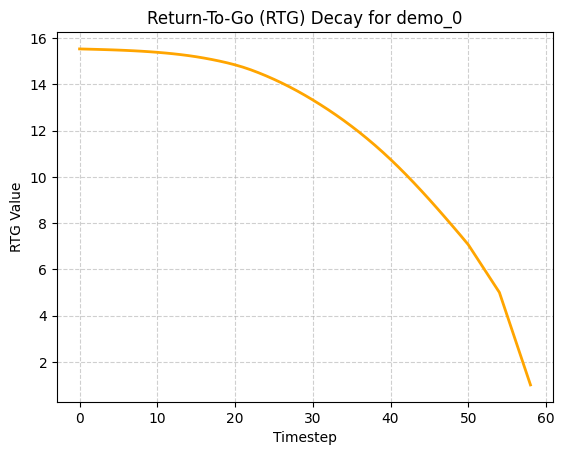

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

with h5py.File(hdf5_path, 'r') as f:
    base_grp = f['data'] if 'data' in f else f

    # Grab the first demo
    demo_keys = [k for k in base_grp.keys() if k.startswith('demo_')]
    first_demo = demo_keys[0]

    rewards = base_grp[first_demo]['rewards'][:]

    print(f"--- Reward Sequence for {first_demo} ---")
    print(f"Total Steps: {len(rewards)}")
    print(f"Total Return: {np.sum(rewards):.2f}\n")

    # Print the first 15 and last 15 steps to see the start/end behavior
    print(f"First 15 steps: {np.round(rewards[:15], 3)}")
    print("...")
    print(f"Last 15 steps:  {np.round(rewards[-15:], 3)}")

    # Optional: Plot the cumulative Return-To-Go curve
    rtg = np.cumsum(rewards[::-1])[::-1]
    plt.plot(rtg, color='orange', linewidth=2)
    plt.title(f"Return-To-Go (RTG) Decay for {first_demo}")
    plt.xlabel("Timestep")
    plt.ylabel("RTG Value")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

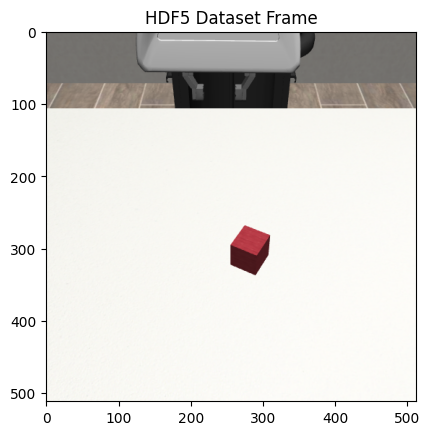

In [ ]:
import matplotlib.pyplot as plt
import h5py

with h5py.File(hdf5_path, 'r') as f:
    # Assuming standard structure
    img = f['data']['demo_0']['obs']['robot0_robotview_image'][0]

    plt.imshow(img)
    plt.title("HDF5 Dataset Frame")
    plt.show()

# 3. Training a Decision Transformer

## Transformer Model

In [ ]:
import torch
import torch.nn as nn

class MicroVLADecisionTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.hidden_dim = config.hidden_dim
        self.dino_dim = 384  # DINOv3 ViT-Small base feature dimension

        # ---------------------------------------------------------
        # 1. Base Embeddings (Action, Reward, Timestep)
        # ---------------------------------------------------------
        if self.config.use_reward_tokens:
            self.embed_reward = nn.Linear(1, self.hidden_dim)

        self.embed_action = nn.Linear(config.action_dim[0], self.hidden_dim)
        self.embed_timestep = nn.Embedding(config.max_ep_len, self.hidden_dim)

        # ---------------------------------------------------------
        # 2. Modality Embeddings (Conditional based on Config)
        # ---------------------------------------------------------
        if self.config.fuse_observations:
            # EARLY FUSION: Concatenate all modalities into one large vector,
            # then process through a small MLP down to hidden_dim.
            concat_dim = (2 * self.dino_dim) + config.obs_dim[0]
            self.embed_obs_fused = nn.Sequential(
                nn.Linear(concat_dim, self.hidden_dim),
                nn.GELU(),
                nn.Linear(self.hidden_dim, self.hidden_dim)
            )
        else:
            # LATE FUSION: Project each modality independently to the hidden_dim
            self.embed_rv = nn.Linear(self.dino_dim, self.hidden_dim)
            self.embed_eye = nn.Linear(self.dino_dim, self.hidden_dim)
            self.embed_proprio = nn.Linear(config.obs_dim[0], self.hidden_dim)

        # ---------------------------------------------------------
        # 3. Core Transformer Architecture
        # ---------------------------------------------------------
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.hidden_dim,
            nhead=config.nhead,
            dim_feedforward=self.hidden_dim * 4,
            dropout=config.dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True  # Pre-LN variant for training stability
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=config.num_layers,
            enable_nested_tensor=False,
        )

        # ---------------------------------------------------------
        # 4. Policy Prediction Head
        # ---------------------------------------------------------
        self.predict_action = nn.Sequential(
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, config.action_dim[0])
        )

    def forward(
        self,
        eef_state: torch.Tensor,
        timesteps: torch.Tensor,
        actions: torch.Tensor,
        rewards: torch.Tensor = None,
        dino_robotview: torch.Tensor = None,
        dino_eye: torch.Tensor = None,
    ) -> torch.Tensor:

        B, K, _ = eef_state.shape

        # Step 1: Base & Timestep Embeddings
        time_emb = self.embed_timestep(timesteps)       # Shape: (B, K, D)
        action_emb = self.embed_action(actions) + time_emb

        if self.config.use_reward_tokens:
            assert rewards is not None, "rewards tensor must be provided when use_reward_tokens is True."
            reward_emb = self.embed_reward(rewards) + time_emb

        # Step 2: Modality Processing & Interleaving
        if self.config.fuse_observations:
            # --- EARLY FUSION MODE (Concatenated Tokens) ---
            obs_concat = torch.cat([dino_eye, dino_robotview, eef_state], dim=-1)
            obs_emb = self.embed_obs_fused(obs_concat) + time_emb

            if self.config.use_reward_tokens:
                # Sequence: [R, O_fused, A]
                stacked_inputs = torch.stack((reward_emb, obs_emb, action_emb), dim=2)
                seq_len_per_timestep = 3
            else:
                # Sequence: [O_fused, A]
                stacked_inputs = torch.stack((obs_emb, action_emb), dim=2)
                seq_len_per_timestep = 2

            sequence_inputs = stacked_inputs.reshape(B, seq_len_per_timestep * K, self.hidden_dim)

        else:
            # --- LATE FUSION MODE (Separate Tokens) ---
            eye_emb = self.embed_eye(dino_eye) + time_emb
            rv_emb = self.embed_rv(dino_robotview) + time_emb
            proprio_emb = self.embed_proprio(eef_state) + time_emb

            if self.config.use_reward_tokens:
                # Sequence: [R, Eye, RV, Proprio, A]
                stacked_inputs = torch.stack((reward_emb, eye_emb, rv_emb, proprio_emb, action_emb), dim=2)
                seq_len_per_timestep = 5
            else:
                # Sequence: [Eye, RV, Proprio, A]
                stacked_inputs = torch.stack((eye_emb, rv_emb, proprio_emb, action_emb), dim=2)
                seq_len_per_timestep = 4

            sequence_inputs = stacked_inputs.reshape(B, seq_len_per_timestep * K, self.hidden_dim)

        # Step 3: Generate Dynamic Causal Masking
        total_seq_len = seq_len_per_timestep * K
        mask = torch.nn.Transformer.generate_square_subsequent_mask(total_seq_len, device=eef_state.device)

        # Step 4: Pass through the core Transformer Layers
        transformer_outputs = self.transformer(sequence_inputs, mask=mask, is_causal=True)

        # Step 5: Extract the Correct Tokens for Action Prediction
        # The model must predict the action from the token IMMEDIATELY PRECEDING the action token
        # so it can causally attend to all current timestep modalities.
        if self.config.fuse_observations:
            if self.config.use_reward_tokens:
                # [R, O, A] -> O is at index 1
                obs_outputs = transformer_outputs[:, 1::seq_len_per_timestep, :]
            else:
                # [O, A] -> O is at index 0
                obs_outputs = transformer_outputs[:, 0::seq_len_per_timestep, :]
        else:
            if self.config.use_reward_tokens:
                # [R, O_eye, O_rv, O_proprio, A] -> O_proprio is at index 3
                obs_outputs = transformer_outputs[:, 3::seq_len_per_timestep, :]
            else:
                # [O_eye, O_rv, O_proprio, A] -> O_proprio is at index 2
                obs_outputs = transformer_outputs[:, 2::seq_len_per_timestep, :]

        # Predict continuous actions: Shape (B, K, action_dim)
        predicted_actions = self.predict_action(obs_outputs)

        return predicted_actions

## Dataset

In [ ]:
import h5py
import numpy as np
import torch
import random
from torch.utils.data import Dataset

class MicroVLADataset(Dataset):
    def __init__(self, hdf5_paths: list[str], config: "Config", use_icl: bool = True, task_to_demos: dict = None):
        """
        Args:
            hdf5_paths: List of paths to task HDF5 files.
            config: Configuration object containing dataset stats and context_len.
            use_icl: If True, fetches a context demo + query demo (length 2K).
                     If False, fetches only the query demo (length K).
            task_to_demos: Optional dict mapping {hdf5_path: [list_of_demo_keys]}.
                           Used to strictly separate train/test splits.
        """
        self.config = config
        self.context_len = config.context_len
        self.hdf5_paths = hdf5_paths
        self.use_icl = use_icl

        self.files = {}
        self.valid_starts = []
        self.task_to_starts = {i: [] for i in range(len(self.hdf5_paths))}

        for task_idx, path in enumerate(self.hdf5_paths):
            with h5py.File(path, 'r') as f:
                base_grp = f['data'] if 'data' in f else f

                # Use provided split keys if available, otherwise use all demos in the file
                if task_to_demos is not None and path in task_to_demos:
                    demos = task_to_demos[path]
                else:
                    demos = [k for k in base_grp.keys() if k.startswith('demo_')]

                for demo in demos:
                    ep_len = base_grp[demo]['actions'].shape[0]
                    for i in range(ep_len):
                        self.valid_starts.append((task_idx, demo, i, ep_len))
                        self.task_to_starts[task_idx].append((demo, i, ep_len))

    def __len__(self):
        return len(self.valid_starts)

    def _pad_tensor(self, tensor: torch.Tensor, pad_len: int) -> torch.Tensor:
        if pad_len == 0:
            return tensor
        pad_shape = list(tensor.shape)
        pad_shape[0] = pad_len
        zeros = torch.zeros(*pad_shape, dtype=tensor.dtype, device=tensor.device)
        return torch.cat([tensor, zeros], dim=0)

    def _get_chunk(self, task_idx: int, demo: str, start: int, ep_len: int):
        """Extracts an UNPADDED trajectory chunk capped at context_len."""
        actual_K = min(self.context_len, ep_len - start)
        end = start + actual_K

        file_handle = self.files[task_idx]
        base_grp = file_handle['data'] if 'data' in file_handle else file_handle
        ep_grp = base_grp[demo]

        obs_slice = {
            'robot0_eef_pos': ep_grp['obs']['robot0_eef_pos'][start:end],
            'robot0_eef_quat': ep_grp['obs']['robot0_eef_quat'][start:end],
            'robot0_gripper_qpos': ep_grp['obs']['robot0_gripper_qpos'][start:end]
        }

        # NOTE: Ensure extract_7dof_state is imported/defined
        state_features = extract_7dof_state(obs_slice)
        state_tensor = torch.tensor(state_features, dtype=torch.float32)

        state_mean = self.config.dataset_stats["observation.state"]["mean"]
        state_std = self.config.dataset_stats["observation.state"]["std"]
        normalized_state = (state_tensor - state_mean) / (state_std + 1e-6)

        dino_rv = torch.tensor(ep_grp['obs']['robot0_robotview_image'][start:end], dtype=torch.float32)
        dino_eye = torch.tensor(ep_grp['obs']['robot0_eye_in_hand_image'][start:end], dtype=torch.float32)
        actions = torch.tensor(ep_grp['actions'][start:end], dtype=torch.float32)

        # -------------------------------------------------------------
        # MODIFIED: Conditionally calculate RTG or use step rewards
        # -------------------------------------------------------------
        if getattr(self.config, 'use_rtg', True): # Defaults to True if flag is missing
            # Returns-to-go (Cumulative future rewards)
            all_future_rewards = ep_grp['rewards'][start:]
            processed_rewards = np.cumsum(all_future_rewards[::-1])[::-1][:actual_K].copy()
        else:
            # Standard single-step rewards
            processed_rewards = ep_grp['rewards'][start:end].copy()

        rewards_tensor = torch.tensor(processed_rewards, dtype=torch.float32).unsqueeze(-1)

        return {
            "eef_state": normalized_state,
            "dino_robotview": dino_rv,
            "dino_eye": dino_eye,
            "actions": actions,
            "rewards": rewards_tensor, # Renamed from "rtg"
            "actual_K": actual_K
        }

    def __getitem__(self, idx):
        if not self.files:
            for i, path in enumerate(self.hdf5_paths):
                self.files[i] = h5py.File(path, 'r')

        task_idx, query_demo, query_start, query_ep_len = self.valid_starts[idx]
        query_chunk = self._get_chunk(task_idx, query_demo, query_start, query_ep_len)

        # Updated key list to use "rewards" instead of "rtg"
        batch_keys = ["eef_state", "dino_robotview", "dino_eye", "actions", "rewards"]

        if self.use_icl:
            # --- ICL MODE: Context + Query ---
            context_demo, context_start, context_ep_len = random.choice(self.task_to_starts[task_idx])
            context_chunk = self._get_chunk(task_idx, context_demo, context_start, context_ep_len)

            total_max_len = 2 * self.context_len
            combined_valid_len = context_chunk["actual_K"] + query_chunk["actual_K"]
            tail_pad_len = total_max_len - combined_valid_len

            combined_batch = {}
            for key in batch_keys:
                unpadded_combined = torch.cat([context_chunk[key], query_chunk[key]], dim=0)
                combined_batch[key] = self._pad_tensor(unpadded_combined, tail_pad_len)

            ctx_time = torch.arange(0, context_chunk["actual_K"], dtype=torch.long)
            query_time = torch.arange(0, query_chunk["actual_K"], dtype=torch.long)
            unpadded_time = torch.cat([ctx_time, query_time], dim=0)
            combined_batch["timesteps"] = self._pad_tensor(unpadded_time, tail_pad_len)

            # Loss Mask: 0 for context, 1 for query, 0 for tail padding
            context_mask = torch.zeros(context_chunk["actual_K"], dtype=torch.float32)
            query_mask = torch.ones(query_chunk["actual_K"], dtype=torch.float32)
            padding_mask = torch.zeros(tail_pad_len, dtype=torch.float32)
            combined_batch["loss_mask"] = torch.cat([context_mask, query_mask, padding_mask], dim=0)

            combined_batch["task_idx"] = torch.tensor(task_idx, dtype=torch.long)

            return combined_batch

        else:
            # --- BASELINE MODE: Query Only ---
            total_max_len = self.context_len
            tail_pad_len = total_max_len - query_chunk["actual_K"]

            baseline_batch = {}
            for key in batch_keys:
                baseline_batch[key] = self._pad_tensor(query_chunk[key], tail_pad_len)

            query_time = torch.arange(0, query_chunk["actual_K"], dtype=torch.long)
            baseline_batch["timesteps"] = self._pad_tensor(query_time, tail_pad_len)

            # Loss Mask: 1 for query, 0 for padding
            query_mask = torch.ones(query_chunk["actual_K"], dtype=torch.float32)
            padding_mask = torch.zeros(tail_pad_len, dtype=torch.float32)
            baseline_batch["loss_mask"] = torch.cat([query_mask, padding_mask], dim=0)

            baseline_batch["task_idx"] = torch.tensor(task_idx, dtype=torch.long)

            return baseline_batch

## Training loop

In [ ]:
import h5py
import random
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm

def train_micro_vla(config, hdf5_paths: list[str], use_icl: bool = True,
                    checkpoint_name: str = "micro_vla_weights.pt", task_weights: dict[str, float] | None = None):
    # -----------------------------------------
    # 1. Create Strict Episode-Level Splits
    # -----------------------------------------
    train_splits = {}
    test_splits = {}

    for path in hdf5_paths:
        with h5py.File(path, 'r') as f:
            base_grp = f['data'] if 'data' in f else f
            all_demos = [k for k in base_grp.keys() if k.startswith('demo_')]

        # Shuffle in-place and calculate the 80/20 index
        random.shuffle(all_demos)
        split_idx = int(0.9 * len(all_demos))

        train_splits[path] = all_demos[:split_idx]
        test_splits[path] = all_demos[split_idx:]

    # -----------------------------------------
    # 2. Instantiate Datasets & DataLoaders
    # -----------------------------------------
    train_dataset = MicroVLADataset(hdf5_paths, config, use_icl=use_icl, task_to_demos=train_splits)
    test_dataset = MicroVLADataset(hdf5_paths, config, use_icl=use_icl, task_to_demos=test_splits)

    # Create Sample Weights for the Sampler
    sample_weights = []
    if task_weights is not None:
        # Strategy A: Use explicit weights provided by you
        for task_idx, _, _, _ in train_dataset.valid_starts:
            path = hdf5_paths[task_idx]
            weight = task_weights.get(path, 1.0)
            sample_weights.append(weight)
    else:
        # Strategy B: Automatic Inverse Frequency (Perfectly balances tasks)
        # First, count how many valid starting indices belong to each task
        task_counts = {i: 0 for i in range(len(hdf5_paths))}
        for task_idx, _, _, _ in train_dataset.valid_starts:
            task_counts[task_idx] += 1

        print(f"TASK COUNTS: {task_counts}")

        # Then, assign a weight that is inversely proportional to its frequency
        for task_idx, _, _, _ in train_dataset.valid_starts:
            # E.g., if task 0 has 10,000 samples, weight is 1/10000.
            weight = 1.0 / (task_counts[task_idx] + 1e-8)
            sample_weights.append(weight)

    # Instantiate the PyTorch Sampler
    if config.steps_per_epoch < len(sample_weights):
        print("NOTE: will omit some trajectories to respect the config steps_per_epoch. Review if this is intended or if you are accidentaly truncating your epochs")
    num_samples = min(config.steps_per_epoch, len(sample_weights))
    train_sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=num_samples, # Number of steps per epoch can be configured.
        replacement=True                 # Must be True to allow oversampling smaller tasks
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        sampler=train_sampler,
        num_workers=2,
        pin_memory=True,
        persistent_workers=True,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        persistent_workers=True,
    )

    # -----------------------------------------
    # 3. Initialize Model & Optimizer
    # -----------------------------------------
    model = MicroVLADecisionTransformer(config).to(config.device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    mode_str = "ICL" if use_icl else "Baseline"
    print(f"Starting {mode_str} training on {config.device}...")
    print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


    # -----------------------------------------
    # 4. Training & Validation Loop
    # -----------------------------------------
    for epoch in range(config.num_epochs):

        # --- TRAINING PHASE ---
        model.train()
        total_train_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.num_epochs} [Train]")

        for batch_idx, batch in enumerate(progress_bar):
            eef_state = batch["eef_state"].to(config.device)
            dino_robotview = batch["dino_robotview"].to(config.device)
            dino_eye = batch["dino_eye"].to(config.device)
            actions = batch["actions"].to(config.device)
            rewards = batch["rewards"].to(config.device)
            timesteps = batch["timesteps"].to(config.device)

            # The unified mask automatically handles ICL context filtering vs baseline padding
            loss_mask = batch["loss_mask"].to(config.device)

            # Forward Pass
            predicted_actions = model(
                eef_state=eef_state,
                rewards=rewards,
                timesteps=timesteps,
                actions=actions,
                dino_robotview=dino_robotview,
                dino_eye=dino_eye
            )

            # Masked Loss Calculation
            raw_loss = F.mse_loss(predicted_actions, actions, reduction='none')
            loss_mask = loss_mask.unsqueeze(-1)
            action_dim = raw_loss.shape[-1]
            masked_loss = (raw_loss * loss_mask).sum() / (loss_mask.sum() * action_dim + 1e-8)

            # Backpropagation
            optimizer.zero_grad()
            masked_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.25)
            optimizer.step()

            # Logging
            total_train_loss += masked_loss.item()
            progress_bar.set_postfix({'loss': f"{masked_loss.item():.4f}"})

        avg_train_loss = total_train_loss / len(train_loader)

        # --- EVALUATION PHASE ---
        model.eval()
        total_test_loss = 0.0

        # NEW: Initialize tracking dictionaries for per-task losses
        num_tasks = len(hdf5_paths)
        task_test_losses = {i: 0.0 for i in range(num_tasks)}
        task_test_counts = {i: 0 for i in range(num_tasks)}

        with torch.no_grad():
            for batch in test_loader:
                eef_state = batch["eef_state"].to(config.device)
                dino_robotview = batch["dino_robotview"].to(config.device)
                dino_eye = batch["dino_eye"].to(config.device)
                actions = batch["actions"].to(config.device)
                rewards = batch["rewards"].to(config.device)
                timesteps = batch["timesteps"].to(config.device)
                loss_mask = batch["loss_mask"].to(config.device)
                task_indices = batch["task_idx"].tolist() # Convert to list for easy iteration

                predicted_actions = model(
                    eef_state=eef_state,
                    rewards=rewards,
                    timesteps=timesteps,
                    actions=actions,
                    dino_robotview=dino_robotview,
                    dino_eye=dino_eye
                )

                # Raw loss shape: [Batch, Time, Action_Dim]
                raw_loss = F.mse_loss(predicted_actions, actions, reduction='none')
                loss_mask_expanded = loss_mask.unsqueeze(-1)

                # 1. Calculate global batch loss (same as before)
                action_dim = raw_loss.shape[-1]
                global_masked_loss = (raw_loss * loss_mask_expanded).sum() / (loss_mask_expanded.sum() * action_dim + 1e-8)
                total_test_loss += global_masked_loss.item()

                # 2. NEW: Calculate loss per trajectory in the batch
                # Sum across Time (dim=1) and Action (dim=2) to get shape: [Batch]
                item_masked_loss = (raw_loss * loss_mask_expanded).sum(dim=(1, 2))
                item_valid_elements = loss_mask.sum(dim=1) * action_dim + 1e-8
                item_loss = item_masked_loss / item_valid_elements # Shape: [Batch]

                # 3. NEW: Route the loss to the correct task tally
                for b_idx in range(len(task_indices)):
                    t_idx = task_indices[b_idx]
                    task_test_losses[t_idx] += item_loss[b_idx].item()
                    task_test_counts[t_idx] += 1

        avg_test_loss = total_test_loss / len(test_loader)

        # --- LOGGING ---
        print(f"\n--- Epoch {epoch+1} Summary | Train Loss: {avg_train_loss:.4f} | Global Test Loss: {avg_test_loss:.4f} ---")

        # Print the breakdown per task
        for i in range(num_tasks):
            if task_test_counts[i] > 0:
                avg_task_loss = task_test_losses[i] / task_test_counts[i]
                # Extracting just the filename for cleaner logging
                task_name = hdf5_paths[i].split("/")[-1]
                print(f"    Task {i} ({task_name}): {avg_task_loss:.4f}")

        torch.save(model.state_dict(), f"epoch{epoch}_{checkpoint_name}")

    # -----------------------------------------
    # 5. Save Model Checkpoint
    # -----------------------------------------
    torch.save(model.state_dict(), checkpoint_name)
    print(f"Training complete. Final epoch model saved as: {checkpoint_name}")

    return model

## Running training

In [ ]:
config = Config(num_epochs=10)


trained_model = train_micro_vla(config, hdf5_paths[0:1], use_icl=True, checkpoint_name="lift_ph.pt")

TASK COUNTS: {0: 8670}
Starting ICL training on cuda...
Train batches: 1084 | Test batches: 125


Epoch 1/10 [Train]:   0%|          | 0/1084 [00:00<?, ?it/s]


--- Epoch 1 Summary | Train Loss: 0.0362 | Global Test Loss: 0.0321 ---
    Task 0 (ph.hdf5): 0.2182


Epoch 2/10 [Train]:   0%|          | 0/1084 [00:00<?, ?it/s]


--- Epoch 2 Summary | Train Loss: 0.0260 | Global Test Loss: 0.0228 ---
    Task 0 (ph.hdf5): 0.1555


...


--- Epoch 8 Summary | Train Loss: 0.0133 | Global Test Loss: 0.0261 ---
    Task 0 (ph.hdf5): 0.1795


Epoch 9/10 [Train]:   0%|          | 0/1084 [00:00<?, ?it/s]


--- Epoch 9 Summary | Train Loss: 0.0123 | Global Test Loss: 0.0230 ---
    Task 0 (ph.hdf5): 0.1573


Epoch 10/10 [Train]:   0%|          | 0/1084 [00:00<?, ?it/s]


--- Epoch 10 Summary | Train Loss: 0.0114 | Global Test Loss: 0.0335 ---
    Task 0 (ph.hdf5): 0.2287
Training complete. Final epoch model saved as: lift_ph.pt


In [ ]:
config = Config(num_epochs=10)


trained_model = train_micro_vla(config, hdf5_paths[0:1], use_icl=False, checkpoint_name="lift_ph_no_icl.pt")

TASK COUNTS: {0: 8696}
Starting Baseline training on cuda...
Train batches: 1087 | Test batches: 122


Epoch 1/10 [Train]:   0%|          | 0/1087 [00:00<?, ?it/s]


--- Epoch 1 Summary | Train Loss: 0.0288 | Global Test Loss: 0.0183 ---
    Task 0 (ph.hdf5): 0.1284


Epoch 2/10 [Train]:   0%|          | 0/1087 [00:00<?, ?it/s]


--- Epoch 2 Summary | Train Loss: 0.0183 | Global Test Loss: 0.0163 ---
    Task 0 (ph.hdf5): 0.1119


...


--- Epoch 8 Summary | Train Loss: 0.0106 | Global Test Loss: 0.0220 ---
    Task 0 (ph.hdf5): 0.1494


Epoch 9/10 [Train]:   0%|          | 0/1087 [00:00<?, ?it/s]


--- Epoch 9 Summary | Train Loss: 0.0097 | Global Test Loss: 0.0208 ---
    Task 0 (ph.hdf5): 0.1413


Epoch 10/10 [Train]:   0%|          | 0/1087 [00:00<?, ?it/s]


--- Epoch 10 Summary | Train Loss: 0.0091 | Global Test Loss: 0.0232 ---
    Task 0 (ph.hdf5): 0.1570
Training complete. Final epoch model saved as: lift_ph_no_icl.pt


In [ ]:
config = Config(num_epochs=10)

task_weights = {
    hdf5_paths[0]: 200.,
    hdf5_paths[1]: 100.,
}
trained_model = train_micro_vla(config, hdf5_paths[0:2], use_icl=True, checkpoint_name="lift_ph_and_mh_better.pt",
                                task_weights=task_weights
                                )

NOTE: will omit some trajectories to respect the config steps_per_epoch. Review if this is intended or if you are accidentaly truncating your epochs
Starting ICL training on cuda...
Train batches: 1125 | Test batches: 217


Epoch 1/10 [Train]:   0%|          | 0/1125 [00:00<?, ?it/s]

KeyboardInterrupt: 

# 4. Evaluation


## Dinov3 Wrapper

In [ ]:
import torch
import numpy as np
from typing import Union, List
from transformers import AutoImageProcessor, AutoModel

class DinoV3Wrapper():
    def __init__(self, config: "Config"):
        self.processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")
        self.processor.size.height = config.image_size
        self.processor.size.width = config.image_size

        self.model = AutoModel.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")
        self.model.config.image_size = config.image_size

        # Cleaned up the variable assignment and saved to self.device
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        # Set the model to evaluation mode (critical for on-the-fly inference)
        self.model.eval()

    def __call__(self, images: Union[np.ndarray, torch.Tensor, List]) -> np.ndarray:
        """
        Processes images on the fly into embeddings, matching the offline HDF5 dataset structure.
        """
        # 1. Process the raw images into PyTorch tensors
        processed_obs = self.processor(images=images, return_tensors="pt")

        # 2. Move the pixel values to the same device as the model
        pixel_values = processed_obs["pixel_values"].to(self.device)

        # 3. Perform the forward pass without tracking gradients
        with torch.no_grad():
            output = self.model(pixel_values)

            # 4. Extract the pooler output and convert back to a numpy array
            embeddings = output["pooler_output"].cpu().numpy()

        return embeddings

## Policy layer

### Abstract interface

In [ ]:
import abc
import numpy as np

class BasePolicy(abc.ABC):
    """
    Abstract base class defining the contract for any policy being evaluated.
    The Evaluation Engine will only interact with these methods.
    """

    @abc.abstractmethod
    def reset(self):
        """
        Clears any internal memory, action-chunking queues, or hidden states
        at the start of a new episode.
        """
        pass

    @abc.abstractmethod
    def get_action(self, obs: dict, context: dict) -> np.ndarray:
        """
        Takes the raw Robosuite observation dictionary and an ICL context dictionary,
        and returns a fully formatted action array ready for the environment.
        """
        pass

    def register_reward(self, reward: float):
        """
        Register a reward from the environment to track returns for RTG calculation.
        """
        pass

### Decision Transformer Wrapper

In [ ]:
import torch
import numpy as np

class DecisionTransformerWrapper(BasePolicy):
    """
    A unified evaluation wrapper for the MicroVLADecisionTransformer.
    Supports both standard autoregressive inference and In-Context Learning (ICL)
    while embedding raw images on the fly via DINOv3 to conserve VRAM.
    """
    def __init__(self, cfg, uses_icl: bool = False):
        self.cfg = cfg
        self.device = cfg.device
        self.uses_icl = uses_icl
        self.current_rtg = cfg.target_return

        # Safely extract the action dim
        self.action_dim = cfg.action_dim[0] if isinstance(cfg.action_dim, (tuple, list)) else cfg.action_dim

        # Extract and cache the normalization stats locally
        self.state_mean = self.cfg.dataset_stats["observation.state"]["mean"].clone().detach().to(torch.float32).to(self.device)
        self.state_std = self.cfg.dataset_stats["observation.state"]["std"].clone().detach().to(torch.float32).to(self.device)

        # 1. Instantiate the Vision Encoder
        print("Loading DINOv3 Vision Encoder...")
        self.vision_encoder = DinoV3Wrapper(cfg)

        # 2. Instantiate the Decision Transformer
        mode_str = "ICL" if self.uses_icl else "Standard"
        print(f"Loading {mode_str} Decision Transformer from checkpoint: {cfg.model_id}")

        # use_precomputed_vision MUST be True since we are passing DINO embeddings
        self.model = MicroVLADecisionTransformer(cfg)

        state_dict = torch.load(cfg.model_id, map_location=self.device)
        self.model.load_state_dict(state_dict, strict=False)

        self.model.to(self.device)
        self.model.eval()

        self.reset()

    def reset(self):
        """Clears all rolling sequence buffers at the start of a new episode."""
        self.state_history = []
        self.action_history = []
        self.rtg_history = []
        self.img_rv_history = []
        self.img_eye_history = []
        self.current_timestep = 0
        self.current_rtg = self.cfg.target_return

    def register_reward(self, reward: float):
        self.current_rtg -= reward

    @torch.no_grad()
    def get_action(self, obs: dict, context: dict = None) -> np.ndarray:
        # --- 1. Process and Embed Live Images ---
        raw_rv = np.flipud(obs["robot0_robotview_image"]).copy()
        rv_embedding = self.vision_encoder(images=raw_rv)
        torch_rv_emb = torch.from_numpy(rv_embedding).squeeze(0).float().to(self.device)
        self.img_rv_history.append(torch_rv_emb)

        raw_eye = np.flipud(obs["robot0_eye_in_hand_image"]).copy()
        eye_embedding = self.vision_encoder(images=raw_eye)
        torch_eye_emb = torch.from_numpy(eye_embedding).squeeze(0).float().to(self.device)
        self.img_eye_history.append(torch_eye_emb)

        # --- 2. Process Proprioception & RTG ---
        proprio = extract_7dof_state(obs)
        state_tensor = torch.tensor(proprio, dtype=torch.float32, device=self.device)
        normalized_state = (state_tensor - self.state_mean) / (self.state_std + 1e-6)

        self.state_history.append(normalized_state)
        self.rtg_history.append(torch.tensor([self.current_rtg], dtype=torch.float32, device=self.device))

        # --- 3. Sliding Window on Query ---
        cap = self.cfg.context_len

        query_states_valid = torch.stack(self.state_history[-cap:])
        query_rtgs_valid = torch.stack(self.rtg_history[-cap:])
        query_img_rvs_valid = torch.stack(self.img_rv_history[-cap:])
        query_img_eyes_valid = torch.stack(self.img_eye_history[-cap:])

        # Setup Query Actions (Shifted with causal placeholder)
        dummy_action = torch.zeros(self.action_dim, dtype=torch.float32, device=self.device)
        if len(self.action_history) == 0:
            query_actions_valid = dummy_action.unsqueeze(0)
        else:
            query_actions_valid = torch.stack(self.action_history[-(cap-1):] + [dummy_action])

        # --- 4. Modality Assembly (ICL vs Standard) ---
        if self.uses_icl and context is not None:
            # Note: `context["img_robotview"]` and `context["img_eye"]` must be pre-embedded
            states = torch.cat([context["eef_state"].to(self.device), query_states_valid], dim=0).unsqueeze(0)
            rtgs = torch.cat([context["rtg"].to(self.device), query_rtgs_valid], dim=0).unsqueeze(0)
            actions = torch.cat([context["actions"].to(self.device), query_actions_valid], dim=0).unsqueeze(0)
            img_rvs = torch.cat([context["img_robotview"].to(self.device), query_img_rvs_valid], dim=0).unsqueeze(0)
            img_eyes = torch.cat([context["img_eye"].to(self.device), query_img_eyes_valid], dim=0).unsqueeze(0)

            # Align Timesteps to match ICL dataset (both start at 0)
            ctx_K = context["eef_state"].shape[0]
            qry_K = query_states_valid.shape[0]
            ctx_time = torch.arange(0, ctx_K, dtype=torch.long, device=self.device)
            qry_time = torch.arange(0, qry_K, dtype=torch.long, device=self.device)
            timesteps = torch.cat([ctx_time, qry_time], dim=0).unsqueeze(0)

        else:
            # Standard Autoregressive Forward
            states = query_states_valid.unsqueeze(0)
            rtgs = query_rtgs_valid.unsqueeze(0)
            actions = query_actions_valid.unsqueeze(0)
            img_rvs = query_img_rvs_valid.unsqueeze(0)
            img_eyes = query_img_eyes_valid.unsqueeze(0)

            # Standard rolling timesteps
            qry_K = query_states_valid.shape[0]
            timesteps = torch.arange(0, qry_K, dtype=torch.long, device=self.device).unsqueeze(0)

        # --- 5. Forward Pass ---
        predicted_actions = self.model(
            eef_state=states,
            rewards=rtgs,
            timesteps=timesteps,
            actions=actions,
            dino_robotview=img_rvs,
            dino_eye=img_eyes
        )

        # --- 6. Extract Action and Cache ---
        action_to_take = predicted_actions[0, -1, :].cpu().numpy()

        self.action_history.append(torch.from_numpy(action_to_take).to(self.device))
        self.current_timestep += 1

        return action_to_take

## Task definitions

Here we will define the definitions of the tasks on which we'll evaluate. Theese should be in the fom of factory functions which return a tuple of (env, ctx)

###  Basic env

In [ ]:
import robosuite
import h5py
import random
import torch
import numpy as np
import torchvision.transforms.functional as TF

def build_standard_env(
    env,
    hdf5_path: str,
    cfg,
    camera_names=["robot0_robotview", "robot0_eye_in_hand"],
    control_freq=20,
    horizon=300
):
    """
    Builds the standard Robosuite Lift environment and extracts a random
    demonstration trajectory from the dataset to serve as the ICL context.
    """
    # 1. Instantiate the Environment
    env = robosuite.make(
        env,
        robots="Panda",
        has_renderer=False,           # Headless for evaluation loops
        has_offscreen_renderer=True,  # Required to grab camera frames
        use_camera_obs=True,
        camera_names=camera_names,
        control_freq=control_freq,
        horizon=horizon,
        camera_heights=512,
        camera_widths=512,
        reward_shaping=True,
    )

    # 2. Extract ICL Context from Dataset
    with h5py.File(hdf5_path, 'r') as f:
        base_grp = f['data'] if 'data' in f else f
        demos = [k for k in base_grp.keys() if k.startswith('demo_')]

        # Pick a random demonstration
        demo = random.choice(demos)
        ep_grp = base_grp[demo]

        ep_len = ep_grp['actions'].shape[0]
        # We extract from the beginning of the episode up to context_len
        K = min(cfg.context_len, ep_len)

        # --- A. Proprioception (State) ---
        obs_slice = {
            'robot0_eef_pos': ep_grp['obs']['robot0_eef_pos'][:K],
            'robot0_eef_quat': ep_grp['obs']['robot0_eef_quat'][:K],
            'robot0_gripper_qpos': ep_grp['obs']['robot0_gripper_qpos'][:K]
        }

        # Ensure extract_7dof_state is in scope
        state_features = extract_7dof_state(obs_slice)  # Shape: (K, 7)
        state_tensor = torch.tensor(state_features, dtype=torch.float32)

        # Normalize State using Config Stats
        state_mean = cfg.dataset_stats["observation.state"]["mean"].clone().detach().to(torch.float32)
        state_std = cfg.dataset_stats["observation.state"]["std"].clone().detach().to(torch.float32)
        normalized_state = (state_tensor - state_mean) / (state_std + 1e-6)

        # --- B. Vision (Dino embeddings)
        raw_rv = torch.tensor(ep_grp['obs']['robot0_robotview_image'][:K], dtype=torch.float32)
        raw_eye = torch.tensor(ep_grp['obs']['robot0_eye_in_hand_image'][:K], dtype=torch.float32)

        # --- C. Actions & Returns-To-Go ---
        actions = torch.tensor(ep_grp['actions'][:K], dtype=torch.float32)

        rewards = ep_grp['rewards'][:]
        # Calculate full trajectory RTG, then slice the first K elements
        rtg_array = np.cumsum(rewards[::-1])[::-1][:K].copy()
        rtg = torch.tensor(rtg_array, dtype=torch.float32).unsqueeze(-1)

    # 3. Package Context Dictionary
    context = {
        "eef_state": normalized_state,
        "img_robotview": raw_rv,
        "img_eye": raw_eye,
        "actions": actions,
        "rtg": rtg
    }

    return env, context

[robosuite WARNING] No private macro file found! (macros.py:57)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:58)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.12/dist-packages/robosuite/scripts/setup_macros.py (macros.py:59)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


### Basic lift

In [ ]:
import robosuite
import h5py
import random
import torch
import numpy as np
import torchvision.transforms.functional as TF

def build_standard_lift(
    hdf5_path: str,
    cfg,
    camera_names=["robot0_robotview", "robot0_eye_in_hand"],
    control_freq=20,
    horizon=300
):
    """
    Builds the standard Robosuite Lift environment and extracts a random
    demonstration trajectory from the dataset to serve as the ICL context.
    """
    # 1. Instantiate the Environment
    env = robosuite.make(
        "Lift",
        robots="Panda",
        has_renderer=False,           # Headless for evaluation loops
        has_offscreen_renderer=True,  # Required to grab camera frames
        use_camera_obs=True,
        camera_names=camera_names,
        control_freq=control_freq,
        horizon=horizon,
        camera_heights=512,
        camera_widths=512,
        reward_shaping=True,
    )

    # 2. Extract ICL Context from Dataset
    with h5py.File(hdf5_path, 'r') as f:
        base_grp = f['data'] if 'data' in f else f
        demos = [k for k in base_grp.keys() if k.startswith('demo_')]

        # Pick a random demonstration
        demo = random.choice(demos)
        ep_grp = base_grp[demo]

        ep_len = ep_grp['actions'].shape[0]
        # We extract from the beginning of the episode up to context_len
        K = min(cfg.context_len, ep_len)

        # --- A. Proprioception (State) ---
        obs_slice = {
            'robot0_eef_pos': ep_grp['obs']['robot0_eef_pos'][:K],
            'robot0_eef_quat': ep_grp['obs']['robot0_eef_quat'][:K],
            'robot0_gripper_qpos': ep_grp['obs']['robot0_gripper_qpos'][:K]
        }

        # Ensure extract_7dof_state is in scope
        state_features = extract_7dof_state(obs_slice)  # Shape: (K, 7)
        state_tensor = torch.tensor(state_features, dtype=torch.float32)

        # Normalize State using Config Stats
        state_mean = cfg.dataset_stats["observation.state"]["mean"].clone().detach().to(torch.float32)
        state_std = cfg.dataset_stats["observation.state"]["std"].clone().detach().to(torch.float32)
        normalized_state = (state_tensor - state_mean) / (state_std + 1e-6)

        # --- B. Vision (Dino embeddings)
        raw_rv = torch.tensor(ep_grp['obs']['robot0_robotview_image'][:K], dtype=torch.float32)
        raw_eye = torch.tensor(ep_grp['obs']['robot0_eye_in_hand_image'][:K], dtype=torch.float32)

        # --- C. Actions & Returns-To-Go ---
        actions = torch.tensor(ep_grp['actions'][:K], dtype=torch.float32)

        rewards = ep_grp['rewards'][:]
        # Calculate full trajectory RTG, then slice the first K elements
        rtg_array = np.cumsum(rewards[::-1])[::-1][:K].copy()
        rtg = torch.tensor(rtg_array, dtype=torch.float32).unsqueeze(-1)

    # 3. Package Context Dictionary
    context = {
        "eef_state": normalized_state,
        "img_robotview": raw_rv,
        "img_eye": raw_eye,
        "actions": actions,
        "rtg": rtg
    }

    return env, context

### Basic stack

In [ ]:
import robosuite
import h5py
import random
import torch
import numpy as np
import torchvision.transforms.functional as TF

def build_standard_stack(
    hdf5_path: str,
    cfg,
    camera_names=["robot0_robotview", "robot0_eye_in_hand"],
    control_freq=20,
    horizon=300
):
    """
    Builds the standard Robosuite Lift environment and extracts a random
    demonstration trajectory from the dataset to serve as the ICL context.
    """
    # 1. Instantiate the Environment
    env = robosuite.make(
        "Stack",
        robots="Panda",
        has_renderer=False,           # Headless for evaluation loops
        has_offscreen_renderer=True,  # Required to grab camera frames
        use_camera_obs=True,
        camera_names=camera_names,
        control_freq=control_freq,
        horizon=horizon,
        camera_heights=512,
        camera_widths=512,
        reward_shaping=True,
    )

    # 2. Extract ICL Context from Dataset
    with h5py.File(hdf5_path, 'r') as f:
        base_grp = f['data'] if 'data' in f else f
        demos = [k for k in base_grp.keys() if k.startswith('demo_')]

        # Pick a random demonstration
        demo = random.choice(demos)
        ep_grp = base_grp[demo]

        ep_len = ep_grp['actions'].shape[0]
        # We extract from the beginning of the episode up to context_len
        K = min(cfg.context_len, ep_len)

        # --- A. Proprioception (State) ---
        obs_slice = {
            'robot0_eef_pos': ep_grp['obs']['robot0_eef_pos'][:K],
            'robot0_eef_quat': ep_grp['obs']['robot0_eef_quat'][:K],
            'robot0_gripper_qpos': ep_grp['obs']['robot0_gripper_qpos'][:K]
        }

        # Ensure extract_7dof_state is in scope
        state_features = extract_7dof_state(obs_slice)  # Shape: (K, 7)
        state_tensor = torch.tensor(state_features, dtype=torch.float32)

        # Normalize State using Config Stats
        state_mean = cfg.dataset_stats["observation.state"]["mean"].clone().detach().to(torch.float32)
        state_std = cfg.dataset_stats["observation.state"]["std"].clone().detach().to(torch.float32)
        normalized_state = (state_tensor - state_mean) / (state_std + 1e-6)

        # --- B. Vision (Dino embeddings)
        raw_rv = torch.tensor(ep_grp['obs']['robot0_robotview_image'][:K], dtype=torch.float32)
        raw_eye = torch.tensor(ep_grp['obs']['robot0_eye_in_hand_image'][:K], dtype=torch.float32)

        # --- C. Actions & Returns-To-Go ---
        actions = torch.tensor(ep_grp['actions'][:K], dtype=torch.float32)

        rewards = ep_grp['rewards'][:]
        # Calculate full trajectory RTG, then slice the first K elements
        rtg_array = np.cumsum(rewards[::-1])[::-1][:K].copy()
        rtg = torch.tensor(rtg_array, dtype=torch.float32).unsqueeze(-1)

    # 3. Package Context Dictionary
    context = {
        "eef_state": normalized_state,
        "img_robotview": raw_rv,
        "img_eye": raw_eye,
        "actions": actions,
        "rtg": rtg
    }

    return env, context

### Silly lift variations

In [ ]:
import robosuite
from robosuite.environments.manipulation.lift import Lift
from robosuite.models.objects import BoxObject, CylinderObject
from robosuite.models.arenas import TableArena
from robosuite.models.tasks import ManipulationTask
from robosuite.utils.placement_samplers import UniformRandomSampler
from robosuite.controllers import load_composite_controller_config

class VariantLift(Lift):
    """
    An advanced subclass of Lift that injects a target object alongside
    multiple distractor objects to test language-driven visual grounding.
    """
    def __init__(self, target_shape="cube", target_rgba=[1, 0, 0, 1], distractors=None, **kwargs):
        self.target_shape = target_shape
        self.target_rgba = target_rgba
        # List of dicts, e.g., [{"shape": "cube", "rgba": [0,0,1,1]}]
        self.distractors = distractors if distractors is not None else []
        super().__init__(**kwargs)

    def _load_model(self):
        super(Lift, self)._load_model()

        # 1. Setup the Arena
        xpos = self.robots[0].robot_model.base_xpos_offset["table"](self.table_full_size[0])
        self.robots[0].robot_model.set_base_xpos(xpos)
        mujoco_arena = TableArena(
            table_full_size=self.table_full_size,
            table_friction=self.table_friction,
            table_offset=self.table_offset,
        )
        mujoco_arena.set_origin([0, 0, 0])

        # 2. Build the Target Object (MUST be named "cube" for success tracking)
        if self.target_shape == "cube":
            self.cube = BoxObject(
                name="cube", size_min=[0.02, 0.02, 0.02], size_max=[0.022, 0.022, 0.022],
                rgba=self.target_rgba, material=None
            )
        elif self.target_shape == "puck":
            self.cube = CylinderObject(
                name="cube", size_min=[0.025, 0.010], size_max=[0.030, 0.015],
                rgba=self.target_rgba, material=None
            )

        all_objects = [self.cube]

        # 3. Build the Distractor Objects
        for i, dist in enumerate(self.distractors):
            d_shape = dist.get("shape", "cube")
            d_rgba = dist.get("rgba", [0.5, 0.5, 0.5, 1])
            d_name = f"distractor_{i}"  # Unique names prevent XML clashes

            if d_shape == "cube":
                d_obj = BoxObject(
                    name=d_name, size_min=[0.02, 0.02, 0.02], size_max=[0.022, 0.022, 0.022],
                    rgba=d_rgba, material=None
                )
            elif d_shape == "puck":
                d_obj = CylinderObject(
                    name=d_name, size_min=[0.025, 0.010], size_max=[0.030, 0.015],
                    rgba=d_rgba, material=None
                )
            all_objects.append(d_obj)

        # 4. Standard Placement and Compilation
        self.placement_initializer = UniformRandomSampler(
            name="ObjectSampler",
            mujoco_objects=all_objects,
            # Widened the spawn area slightly from the default so
            # multiple objects have room to spawn without colliding
            x_range=[-0.03, 0.03],
            y_range=[-0.03, 0.03],
            rotation=None,
            ensure_object_boundary_in_range=False,
            ensure_valid_placement=True,
            reference_pos=self.table_offset,
            z_offset=0.01,
        )

        self.model = ManipulationTask(
            mujoco_arena=mujoco_arena,
            mujoco_robots=[robot.robot_model for robot in self.robots],
            mujoco_objects=all_objects,
        )

In [ ]:
def build_color_varied_lift(
    camera_names=["robot0_robotview", "robot0_eye_in_hand"],
    color_name: str = "blue",
    rgba: list = [0, 0, 1, 1],
    control_freq=20,
    horizon=300,
):
    """Builds a Lift task with a uniquely colored cube."""

    env = robosuite.make(
        "VariantLift",                  # <--- Using our new subclass!
        target_shape="cube",
        target_rgba=rgba,               # Injecting the color
        robots="Panda",
        has_renderer=False,
        has_offscreen_renderer=True,
        use_camera_obs=True,
        camera_names=camera_names,
        control_freq=control_freq,
        horizon=horizon,
        camera_heights=512,
        camera_widths=512,
        reward_shaping=True,
    )

    context = {
        "eef_state": None,
        "img_robotview": None,
        "img_eye": None,
        "actions": None,
        "rtg": None,
    }
    return env, context

In [ ]:
def build_color_varied_lift_with_distractor(
    camera_names=["robot0_robotview", "robot0_eye_in_hand"],
    color_name: str = "blue",
    rgba: list = [0, 0, 1, 1],
    distractor_rgba = [1, 0, 0, 1],
    control_freq=20,
    horizon=300,
):
    """Builds a Lift task with two uniquely ocloured cubes - and asks to pick up one of them."""

    env = robosuite.make(
        "VariantLift",
        target_shape="cube",
        target_rgba=rgba,
        distractors=[
            {"shape": "cube", "rgba": distractor_rgba}
        ],
        robots="Panda",
        has_renderer=False,
        has_offscreen_renderer=True,
        use_camera_obs=True,
        camera_names=camera_names,
        control_freq=control_freq,
        horizon=horizon,
        reward_shaping=True,
        camera_heights=512,
        camera_widths=512,
    )

    instruction = f"lift the {color_name} block"
    return env, instruction

In [ ]:
def build_puck_lift(
    camera_names=["robot0_robotview", "robot0_eye_in_hand"],
    control_freq=20,
    horizon=300
):
    """
    Tests if the robot can pick up a puck shaped object
    """

    env = robosuite.make(
        "VariantLift",
        target_shape="puck",
        target_rgba=[1, 0, 0, 1],         # Target: Red Puck
        robots="Panda",
        has_renderer=False,
        has_offscreen_renderer=True,
        use_camera_obs=True,
        camera_names=camera_names,
        control_freq=control_freq,
        horizon=horizon,
        reward_shaping=True,
        camera_heights=512,
        camera_widths=512,
    )

    instruction = "lift the red puck"
    return env, instruction

## Eval runner

In [ ]:
import os
import json
import imageio
import numpy as np
from datetime import datetime

class BenchmarkSuite:
    """
    A standardized suite of tasks to evaluate ICL-conditioned policies.
    """
    def __init__(self, tasks_dict, output_dir="eval_results", num_episodes=10, save_videos=True, success_hold_steps=8):
        self.tasks_dict = tasks_dict
        self.output_dir = output_dir
        self.num_episodes = num_episodes
        self.save_videos = save_videos
        # This now acts as our recording buffer rather than a strict success criteria
        self.success_hold_steps = success_hold_steps

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.run_dir = os.path.join(self.output_dir, f"benchmark_{timestamp}")
        os.makedirs(self.run_dir, exist_ok=True)

    def _run_episode(self, env, policy, context, episode_idx):
        """Runs a single episode conditioned on a demonstration context."""
        obs = env.reset()
        policy.reset()

        frames = []
        success = False
        slipped = False
        post_success_frames = 0

        for step in range(env.horizon):
            action = policy.get_action(obs, context)
            obs, reward, done, info = env.step(action)

            if hasattr(policy, "register_reward"):
                policy.register_reward(reward)

            if self.save_videos:
                frames.append(np.flipud(obs["robot0_robotview_image"]))

            is_current_success = env._check_success()

            # Trigger success on a single frame
            if not success and is_current_success:
                success = True
                # \n added to avoid overwriting the \r progress bar from the parent loop
                print(f"\n      -> Success reached at step {step}! Recording {self.success_hold_steps} trailing frames...")

            # If we've hit success at least once, start tracking buffer and slippage
            if success:
                if not is_current_success and not slipped:
                    slipped = True
                    print(f"      -> Warning: Success condition slipped at step {step}!")

                post_success_frames += 1
                if post_success_frames >= self.success_hold_steps:
                    break

        return success, frames, slipped

    def _evaluate_task(self, policy, task_name, task_builder, policy_dir):
        """Evaluates a policy on a single task and saves the outputs."""
        print(f"\n  --- Task: {task_name} ---")

        # task_builder must now return the environment and the context dictionary
        env, context = task_builder()

        task_dir = os.path.join(policy_dir, task_name)
        os.makedirs(task_dir, exist_ok=True)

        successes = 0
        slips = 0

        for ep_idx in range(self.num_episodes):
            print(f"    [Ep {ep_idx+1}/{self.num_episodes}] Rolling out with ICL Context...", end="\r")

            # Unpack the newly added slipped variable
            success, frames, slipped = self._run_episode(env, policy, context, ep_idx)

            print(f"    [Ep {ep_idx+1}/{self.num_episodes}] Status:", end="")
            if success:
                successes += 1
                if slipped:
                    slips += 1
                    print("      -> Success (but slipped).")
                else:
                    print("      -> Success.")
            else:
                print("      -> Failed.")

            if self.save_videos:
                # Add "slipped" to the filename for easy debugging later
                status = "success" if success else "fail"
                if success and slipped:
                    status = "success_slipped"

                video_path = os.path.join(task_dir, f"ep_{ep_idx:02d}_{status}.mp4")
                writer = imageio.get_writer(video_path, fps=env.control_freq)
                for f in frames:
                    writer.append_data(f)
                writer.close()

        env.close()

        success_rate = successes / self.num_episodes
        slip_rate = (slips / successes) if successes > 0 else 0.0

        print(f"  --- {task_name} | Success Rate: {success_rate:.0%} | Slip Rate (of successes): {slip_rate:.0%} ---")

        return {
            "success_rate": success_rate,
            "total_episodes": self.num_episodes,
            "successful_episodes": successes,
            "slipped_episodes": slips,
            "slip_rate_among_successes": slip_rate
        }

    def evaluate_policy(self, policy, policy_name: str):
        """Runs a specific policy through the entire task suite."""
        print(f"\n{'='*50}\nEvaluating Policy: {policy_name}\n{'='*50}")

        policy_dir = os.path.join(self.run_dir, policy_name)
        os.makedirs(policy_dir, exist_ok=True)

        policy_results = {}
        for task_name, task_builder in self.tasks_dict.items():
            task_metrics = self._evaluate_task(policy, task_name, task_builder, policy_dir)
            policy_results[task_name] = task_metrics

        report_path = os.path.join(policy_dir, f"{policy_name}_report.json")
        with open(report_path, "w") as f:
            json.dump(policy_results, f, indent=4)

        return policy_results

## Eval run

In [ ]:
# 1. Define the Benchmark Suite (The Tasks)
tasks_to_evaluate = {
    "Standard_Lift": lambda: build_standard_lift(cfg=Config(), hdf5_path=hdf5_paths[0], horizon=100),
    #"Standard_Stack": lambda: build_standard_stack(cfg=Config(), hdf5_path=hdf5_paths[1], horizon=150),
    "Red_Cube_Lift": lambda: build_color_varied_lift(horizon=100, rgba=[1,0,0,1]),
    #"Blue_Cube_Lift": lambda: build_color_varied_lift(horizon=100, rgba=[0,0,1,1]),
    #"Green_Cube_Lift": lambda: build_color_varied_lift(horizon=100, rgba=[0,1,0,1]),
    # "Blue_Cube_With_Distractor_Lift": lambda: build_color_varied_lift_with_distractor(horizon=10),
    # "Puck_Lift": lambda: build_puck_lift(horizon=100),
}

# 2. Initialize the Benchmark Engine
benchmark = BenchmarkSuite(
    tasks_dict=tasks_to_evaluate,
    output_dir="./vla_evaluations",
    num_episodes=8,
    save_videos=True
)

# 3. Define the Models to Evaluate
# In practice, your teammate might populate this list dynamically from a checkpoints folder
policies_to_test = {
    # "ICL_TRAINED": lambda: DecisionTransformerWrapper(
    #     Config(model_id="./lift_ph.pt", ), uses_icl=False),
    "NON_ICL_TRAINED": lambda: DecisionTransformerWrapper(
        Config(model_id="./lift_ph_no_icl.pt", ), uses_icl=False),
    # "ICL": lambda: DecisionTransformerICLWrapper(
    #     Config(model_id="./icl_weights.pt", context_len=100)
    # )
}

# 4. Run the Evaluations
all_results = {}

for policy_name, policy_ctor in policies_to_test.items():
    # Instantiate the brain
    policy = policy_ctor()

    # Test the brain against the suite
    results = benchmark.evaluate_policy(policy, policy_name=policy_name)
    all_results[policy_name] = results

    # Optional: Delete the policy from memory to prevent VRAM overflow when loading the next one
    del policy

print("\nAll models evaluated successfully!")


Loading DINOv3 Vision Encoder...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[robosuite INFO] Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/robots/default_panda.json


Loading Standard Decision Transformer from checkpoint: ./lift_ph_no_icl.pt

Evaluating Policy: NON_ICL_TRAINED

  --- Task: Standard_Lift ---


[robosuite INFO] Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/robots/default_panda.json


...

    [Ep 6/8] Rolling out with ICL Context...
      -> Success reached at step 50! Recording 8 trailing frames...
    [Ep 6/8] Status:      -> Success.


[robosuite INFO] Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/robots/default_panda.json


    [Ep 7/8] Rolling out with ICL Context...
      -> Success reached at step 54! Recording 8 trailing frames...
      -> Warning: Success condition slipped at step 58!
    [Ep 7/8] Status:      -> Success (but slipped).


[robosuite INFO] Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/robots/default_panda.json


    [Ep 8/8] Rolling out with ICL Context...
      -> Success reached at step 57! Recording 8 trailing frames...
    [Ep 8/8] Status:      -> Success.
  --- Red_Cube_Lift | Success Rate: 62% | Slip Rate (of successes): 20% ---

All models evaluated successfully!


## ETc


In [ ]:
from IPython.display import Video

# Replace with your actual file path
video_path = "./vla_evaluations/benchmark_20260602_151140/Sometimes_Successful/Standard_Lift/ep_00_success.mp4"

# Render the video
Video(video_path, width=640, height=360, embed=True)

In [ ]:
! ls -lah ./vla_evaluations/benchmark_20260602_121309/Sometimes_Successful/Standard_Lift/ep_00_fail.mp4

-rw-r--r-- 1 root root 39K Jun  2 12:14 ./vla_evaluations/benchmark_20260602_121309/Sometimes_Successful/Standard_Lift/ep_00_fail.mp4


In [ ]:
import torch
import torch.nn.functional as F
import gc

def find_max_context_length(config, starting_k=50, step=50):
    print(f"--- Starting VRAM Stress Test on {config.device} ---")
    print(f"Batch Size: {config.batches_per_gradient}")
    print(f"Hidden Dim: {config.hidden_dim}\n")

    current_k = starting_k

    while True:
        try:
            # 1. Force completely clean memory before each test
            gc.collect()
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()

            print(f"Testing Context Length (K) = {current_k} ...", end=" ")

            # 2. Temporarily update the config max_ep_len if K exceeds it
            if current_k > config.max_ep_len:
                config.max_ep_len = current_k + 100

            # 3. Instantiate a fresh model
            model = MicroVLADecisionTransformer(config, use_precomputed_vision=True).to(config.device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
            model.train()

            # 4. Generate Dummy Tensors (B, K, Dim)
            B = 64
            K = current_k

            eef_state = torch.randn(B, K, config.obs_dim[0], device=config.device)
            dino_rv = torch.randn(B, K, 384, device=config.device)
            dino_eye = torch.randn(B, K, 384, device=config.device)
            actions = torch.randn(B, K, config.action_dim[0], device=config.device)
            rtg = torch.randn(B, K, 1, device=config.device)

            # Timesteps must be integers
            timesteps = torch.arange(0, K, dtype=torch.long, device=config.device).unsqueeze(0).expand(B, -1)

            # 5. Simulate one full training step
            optimizer.zero_grad()

            preds = model(
                eef_state=eef_state,
                rtg=rtg,
                timesteps=timesteps,
                actions=actions,
                dino_robotview=dino_rv,
                dino_eye=dino_eye
            )

            loss = F.mse_loss(preds, actions)
            loss.backward()
            optimizer.step()

            # 6. Measure the memory peak
            peak_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
            print(f"Success! Peak VRAM: {peak_memory_gb:.2f} GB")

            # 7. Clean up this iteration completely
            del model, optimizer, eef_state, dino_rv, dino_eye, actions, rtg, timesteps, preds, loss

            # Step up for the next loop
            current_k += step

        except RuntimeError as e:
            if "OutOfMemoryError" in str(e) or "out of memory" in str(e):
                print(f"\n❌ FAILED at Context Length (K) = {current_k}!")
                print(f"CUDA Out of Memory. Your absolute ceiling at batch size {config.batches_per_gradient} is {current_k - step}.")

                # Clean up the crashed tensors
                torch.cuda.empty_cache()
                break
            else:
                # If it crashed for a different reason, raise the error
                raise e

# Grab your base config
test_config = Config()

# If you want to test the default batch size of 64:
find_max_context_length(test_config, starting_k=50, step=50)

# TIP: If it fails too early, uncomment this to see how high K can go with a smaller batch size!
# test_config.batches_per_gradient = 16
# print("\n--- Retrying with smaller batch size ---")
# find_max_context_length(test_config, starting_k=100, step=50)

--- Starting VRAM Stress Test on cuda ---
Batch Size: 8
Hidden Dim: 256

Testing Context Length (K) = 50 ... Success! Peak VRAM: 0.64 GB


/tmp/ipykernel_8604/2876045404.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config.num_layers)


Testing Context Length (K) = 100 ... Success! Peak VRAM: 1.23 GB
Testing Context Length (K) = 150 ... Success! Peak VRAM: 1.80 GB
Testing Context Length (K) = 200 ... Success! Peak VRAM: 2.38 GB
Testing Context Length (K) = 250 ... Success! Peak VRAM: 2.97 GB
Testing Context Length (K) = 300 ... Success! Peak VRAM: 3.55 GB
Testing Context Length (K) = 350 ... Success! Peak VRAM: 4.12 GB
Testing Context Length (K) = 400 ... Success! Peak VRAM: 4.71 GB
Testing Context Length (K) = 450 ... Success! Peak VRAM: 5.29 GB
Testing Context Length (K) = 500 ... Success! Peak VRAM: 5.88 GB
Testing Context Length (K) = 550 ... Success! Peak VRAM: 6.45 GB
Testing Context Length (K) = 600 ... Success! Peak VRAM: 7.03 GB
Testing Context Length (K) = 650 ... Success! Peak VRAM: 7.61 GB
Testing Context Length (K) = 700 ... Success! Peak VRAM: 8.20 GB
Testing Context Length (K) = 750 ... Success! Peak VRAM: 8.77 GB
Testing Context Length (K) = 800 ... Success! Peak VRAM: 9.35 GB
Testing Context Length (K

In [ ]:
import torch
import torch.nn.functional as F
import gc

def find_max_layers(config, fixed_k=300, starting_layers=1, step=1):
    print(f"--- Starting VRAM Stress Test for Network Depth ---")
    print(f"Fixed Context Length (K): {fixed_k}")
    print(f"Batch Size: {config.batches_per_gradient}")
    print(f"Hidden Dim: {config.hidden_dim}\n")

    current_layers = starting_layers

    while True:
        try:
            # 1. Force completely clean memory before each test
            gc.collect()
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()

            print(f"Testing Model Depth = {current_layers} Layers ...", end=" ")

            # 2. Update config dynamically
            config.num_layers = current_layers
            config.context_len = fixed_k
            config.max_ep_len = fixed_k + 100

            # 3. Instantiate a fresh model
            model = MicroVLADecisionTransformer(config, use_precomputed_vision=True).to(config.device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
            model.train()

            # 4. Generate Dummy Tensors (B, K, Dim)
            B = 64
            K = fixed_k

            eef_state = torch.randn(B, K, config.obs_dim[0], device=config.device)
            dino_rv = torch.randn(B, K, 384, device=config.device)
            dino_eye = torch.randn(B, K, 384, device=config.device)
            actions = torch.randn(B, K, config.action_dim[0], device=config.device)
            rtg = torch.randn(B, K, 1, device=config.device)

            timesteps = torch.arange(0, K, dtype=torch.long, device=config.device).unsqueeze(0).expand(B, -1)

            # 5. Simulate one full training step
            optimizer.zero_grad()

            preds = model(
                eef_state=eef_state,
                rtg=rtg,
                timesteps=timesteps,
                actions=actions,
                dino_robotview=dino_rv,
                dino_eye=dino_eye
            )

            loss = F.mse_loss(preds, actions)
            loss.backward()
            optimizer.step()

            # 6. Measure the memory peak
            peak_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
            print(f"Success! Peak VRAM: {peak_memory_gb:.2f} GB")

            # 7. Clean up this iteration completely
            del model, optimizer, eef_state, dino_rv, dino_eye, actions, rtg, timesteps, preds, loss

            current_layers += step

        except RuntimeError as e:
            if "OutOfMemoryError" in str(e) or "out of memory" in str(e):
                print(f"\n❌ FAILED at Model Depth = {current_layers} Layers!")
                print(f"CUDA Out of Memory. At Context Length {fixed_k}, your absolute layer ceiling is {current_layers - step}.")
                torch.cuda.empty_cache()
                break
            else:
                raise e

# Initialize your config
layer_test_config = Config()

# Let's lock K at 300 and step up the layers one by one
find_max_layers(layer_test_config, fixed_k=300, starting_layers=1, step=1)

--- Starting VRAM Stress Test for Network Depth ---
Fixed Context Length (K): 300
Batch Size: 8
Hidden Dim: 256

Testing Model Depth = 1 Layers ... 

/tmp/ipykernel_2773/2876045404.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config.num_layers)


Success! Peak VRAM: 1.72 GB
Testing Model Depth = 2 Layers ... Success! Peak VRAM: 2.74 GB
Testing Model Depth = 3 Layers ... Success! Peak VRAM: 3.77 GB
Testing Model Depth = 4 Layers ... Success! Peak VRAM: 4.79 GB
Testing Model Depth = 5 Layers ... Success! Peak VRAM: 5.81 GB
Testing Model Depth = 6 Layers ... Success! Peak VRAM: 6.84 GB
Testing Model Depth = 7 Layers ... Success! Peak VRAM: 7.86 GB
Testing Model Depth = 8 Layers ... Success! Peak VRAM: 8.89 GB
Testing Model Depth = 9 Layers ... Success! Peak VRAM: 9.91 GB
Testing Model Depth = 10 Layers ... Success! Peak VRAM: 10.93 GB
Testing Model Depth = 11 Layers ... Success! Peak VRAM: 11.96 GB
Testing Model Depth = 12 Layers ... Success! Peak VRAM: 12.98 GB
Testing Model Depth = 13 Layers ... Success! Peak VRAM: 14.01 GB
Testing Model Depth = 14 Layers ... 
❌ FAILED at Model Depth = 14 Layers!
CUDA Out of Memory. At Context Length 300, your absolute layer ceiling is 13.
